In [3]:
import argparse
import os
import sys
from typing import Optional, Tuple

import h5py
import numpy as np
import scipy.io as sio

from models import utils
import os
import time
import numpy as np
import scipy.io as sio
import torch
from torch.utils.data import DataLoader 
from models import utils, parser_ops, UnrollNet
from models.modules import MixL1L2Loss, Dataset, Dataset_Inference, train, validation, test
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
parser = parser_ops.get_parser()
args = parser.parse_args([])

In [4]:
data = sio.loadmat(args.data_dir) 
kspace_train,full_kspace, sens_maps, original_mask= data['kspace'], data['full_kspace'], data['sens_maps'], data['mask']
args.nrow_GLOB, args.ncol_GLOB, args.ncoil_GLOB  = kspace_train.shape

#Normalize the kspace to 0-1 region
kspace_train= kspace_train / np.max(np.abs(kspace_train[:]))


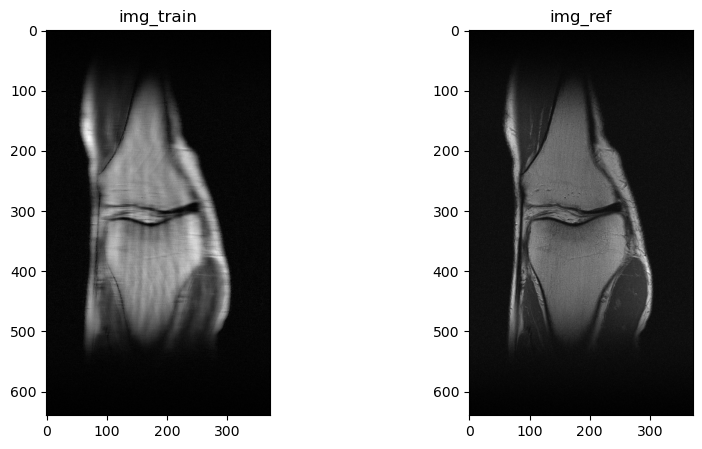

In [7]:
# reconstruct the kspace_train
img_train = utils.sense1(kspace_train, sens_maps)
img_ref = utils.sense1(full_kspace, sens_maps)

# plot the img_train and img_ref
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.abs((img_train[:, :]) ), cmap='gray')
plt.title('img_train')
plt.subplot(1, 2, 2)
plt.imshow(np.abs((img_ref[:, :]) ), cmap='gray')
plt.title('img_ref')
plt.show()
# plot kspace_trai
